# 💼 E-Commerce Sales Analysis — Project 1

> **Goal:** Uncover actionable trends in revenue, seasonality, and demographics from superstore sales data (2011–2014).

---
**Sections:**
1. Setup & Data Loading
2. Data Cleaning & Feature Engineering
3. KPI Summary (YOY Revenue, Profit, Margin)
4. Monthly Sales & Profit Seasonality
5. Category & Sub-Category Analysis
6. Geographic Sales Distribution
7. Segment Performance Analysis
8. Ship Mode & Discount Impact
9. Interactive Filter Dashboard (ipywidgets)


## 1️⃣ Setup & Data Loading

In [5]:
# Install required libraries (run once in Colab)
!pip install openpyxl matplotlib seaborn plotly ipywidgets -q

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ── Global Aesthetic Theme ──────────────────────────────────────────
PALETTE    = ['#4F46E5', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#06B6D4']
BG         = '#0F172A'   # dark navy background
PANEL      = '#1E293B'   # slightly lighter panels
TEXT       = '#F1F5F9'   # near-white text
ACCENT     = '#4F46E5'   # indigo accent
GRID       = '#334155'   # subtle gridlines

plt.rcParams.update({
    'figure.facecolor' : BG,
    'axes.facecolor'   : PANEL,
    'axes.edgecolor'   : GRID,
    'axes.labelcolor'  : TEXT,
    'axes.titlecolor'  : TEXT,
    'text.color'       : TEXT,
    'xtick.color'      : TEXT,
    'ytick.color'      : TEXT,
    'grid.color'       : GRID,
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.4,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

print('✅ Libraries loaded & theme configured.')

✅ Libraries loaded & theme configured.


In [7]:

from google.colab import files
uploaded = files.upload()

FILE = 'Project_1Ecommerce Sales Analysis.xlsx'

df = pd.read_excel(FILE, sheet_name='Data')
print(f'📦 Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Saving Project_1Ecommerce Sales Analysis.xlsx to Project_1Ecommerce Sales Analysis (1).xlsx
📦 Dataset shape: 9,994 rows × 22 columns


,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2013-138688,2013,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


## 2️⃣ Data Cleaning & Feature Engineering

In [8]:
# Date parsing
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# New columns
df['Month']        = df['Order Date'].dt.month
df['Month Name']   = df['Order Date'].dt.strftime('%b')
df['Year']         = df['Order Date'].dt.year
df['Profit Margin']= (df['Profit'] / df['Sales']) * 100
df['Ship Days']    = (df['Ship Date'] - df['Order Date']).dt.days

# Check for nulls
null_counts = df.isnull().sum()
print('Null values per column:')
print(null_counts[null_counts > 0] if null_counts.sum() else '  ✅ None found')

print(f'\nYears covered : {sorted(df["Year"].unique())}')
print(f'Total Sales   : ${df["Sales"].sum():,.0f}')
print(f'Total Profit  : ${df["Profit"].sum():,.0f}')
print(f'Avg Margin    : {df["Profit Margin"].mean():.1f}%')

Null values per column:
  ✅ None found

Years covered : [np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014)]
Total Sales   : $2,297,201
Total Profit  : $286,397
Avg Margin    : 12.0%


## 3️⃣ KPI Summary — Year-over-Year Performance

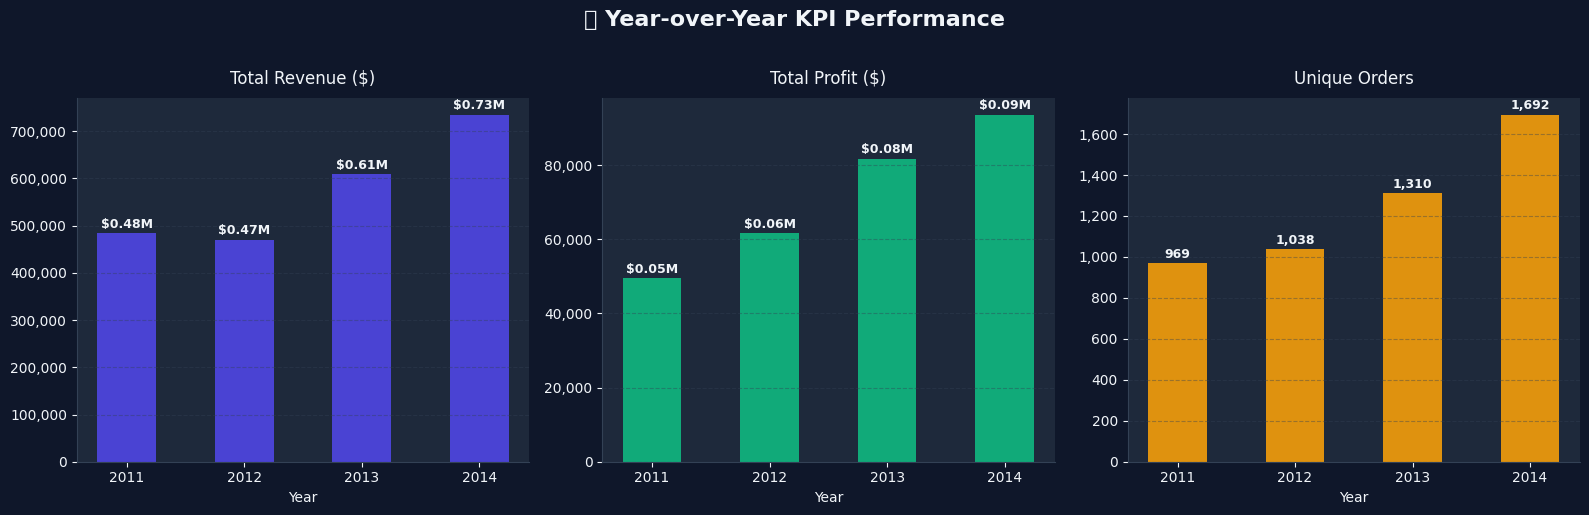


📈 YOY Summary Table:


,Year,Revenue,Profit,Orders,Rev Growth %,Prof Growth %,Margin %
0,2011,484247.5,49544.0,969,NaN,NaN,10.2
1,2012,470532.5,61618.6,1038,-2.8,24.4,13.1
2,2013,608473.8,81726.9,1310,29.3,32.6,13.4
3,2014,733947.0,93507.5,1692,20.6,14.4,12.7


In [9]:
yoy = df.groupby('Year').agg(
    Revenue   = ('Sales',  'sum'),
    Profit    = ('Profit', 'sum'),
    Orders    = ('Order ID', 'nunique'),
).reset_index()

yoy['Rev Growth %']  = yoy['Revenue'].pct_change() * 100
yoy['Prof Growth %'] = yoy['Profit'].pct_change() * 100
yoy['Margin %']      = (yoy['Profit'] / yoy['Revenue']) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('📊 Year-over-Year KPI Performance', fontsize=16, fontweight='bold', y=1.02)

metrics = [
    ('Revenue',  'Total Revenue ($)', PALETTE[0]),
    ('Profit',   'Total Profit ($)',  PALETTE[1]),
    ('Orders',   'Unique Orders',     PALETTE[2]),
]

for ax, (col, label, color) in zip(axes, metrics):
    bars = ax.bar(yoy['Year'].astype(str), yoy[col], color=color, width=0.5,
                  edgecolor='none', alpha=0.9)
    # value labels on bars
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.01,
                f'${h/1e6:.2f}M' if col in ('Revenue','Profit') else f'{int(h):,}',
                ha='center', va='bottom', fontsize=9, color=TEXT, fontweight='bold')
    ax.set_title(label, fontsize=12, pad=10)
    ax.set_xlabel('Year')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'${x/1e6:.1f}M' if col in ('Revenue','Profit') else f'{int(x):,}'
    ))
    ax.grid(axis='y')

plt.tight_layout()
plt.show()

print('\n📈 YOY Summary Table:')
display(yoy.round(1))

## 4️⃣ Monthly Sales & Profit Seasonality

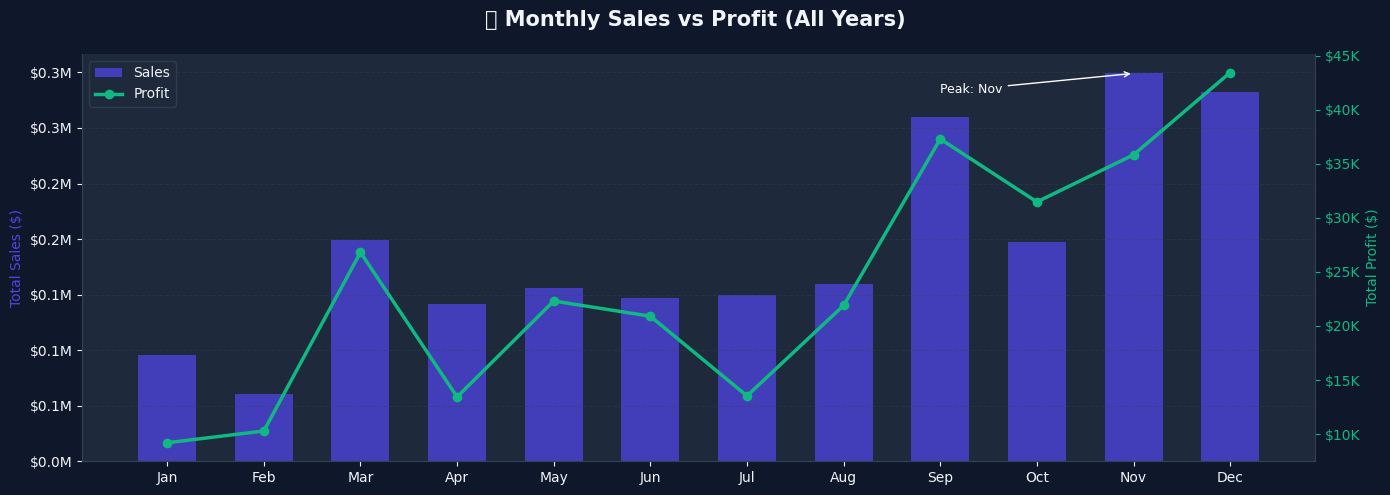

In [10]:
MONTHS_ORDER = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

monthly = df.groupby('Month Name').agg(
    Sales  = ('Sales',  'sum'),
    Profit = ('Profit', 'sum'),
).reindex(MONTHS_ORDER).reset_index()
monthly.columns = ['Month', 'Sales', 'Profit']

fig, ax1 = plt.subplots(figsize=(14, 5))
fig.suptitle('📅 Monthly Sales vs Profit (All Years)', fontsize=15, fontweight='bold')

x = range(len(monthly))
bars = ax1.bar(x, monthly['Sales'], color=PALETTE[0], alpha=0.75, label='Sales', width=0.6)
ax1.set_ylabel('Total Sales ($)', color=PALETTE[0])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e6:.1f}M'))
ax1.set_xticks(x)
ax1.set_xticklabels(monthly['Month'])

ax2 = ax1.twinx()
ax2.plot(x, monthly['Profit'], color=PALETTE[1], linewidth=2.5,
         marker='o', markersize=6, label='Profit')
ax2.set_ylabel('Total Profit ($)', color=PALETTE[1])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e3:.0f}K'))
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color(GRID)
ax2.tick_params(axis='y', colors=PALETTE[1])

# Highlight peak month
peak_idx = monthly['Sales'].idxmax()
ax1.annotate(f"Peak: {monthly.loc[peak_idx,'Month']}",
             xy=(peak_idx, monthly.loc[peak_idx,'Sales']),
             xytext=(peak_idx - 2, monthly['Sales'].max() * 0.95),
             arrowprops=dict(arrowstyle='->', color='white'),
             color='white', fontsize=9)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
           facecolor=PANEL, edgecolor=GRID)
ax1.grid(axis='y')
plt.tight_layout()
plt.show()

## 5️⃣ Category & Sub-Category Analysis

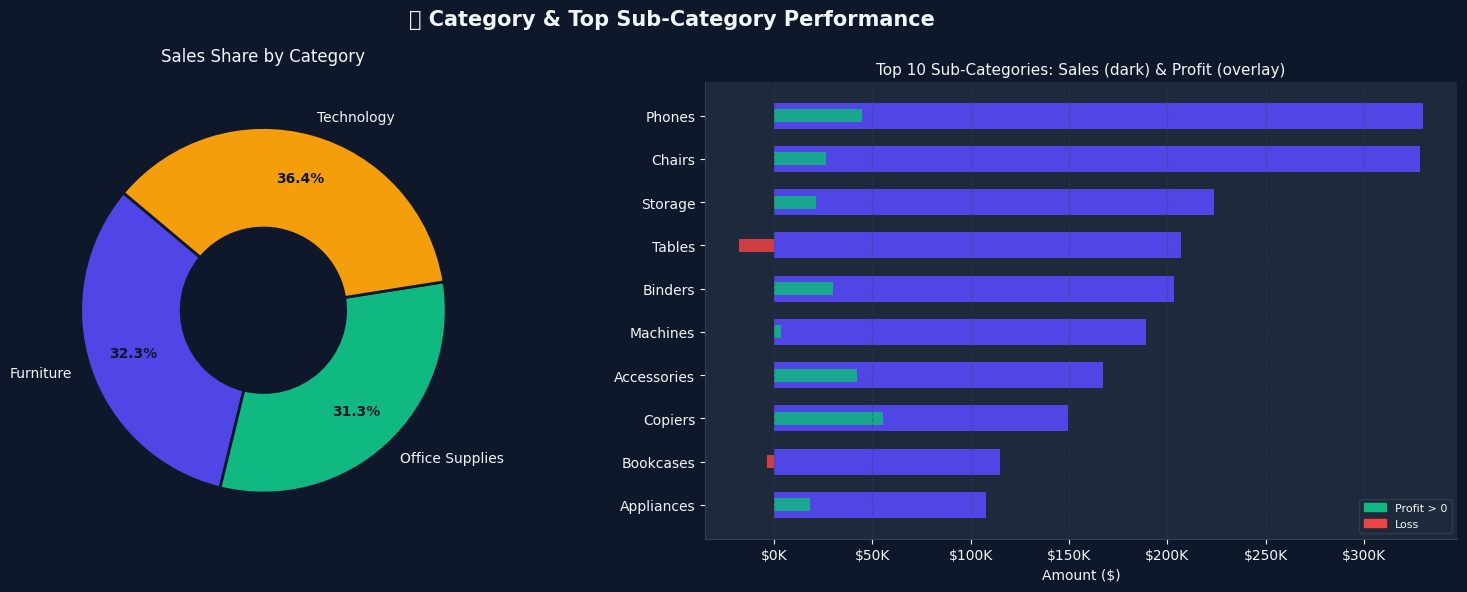

In [11]:
cat = df.groupby('Category').agg(Sales=('Sales','sum'), Profit=('Profit','sum')).reset_index()
subcat = df.groupby('Sub-Category').agg(Sales=('Sales','sum'), Profit=('Profit','sum')) \
           .sort_values('Sales', ascending=False).head(10).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('📦 Category & Top Sub-Category Performance', fontsize=15, fontweight='bold')

# ── Donut chart: Category Sales Share ──
ax = axes[0]
wedge_colors = [PALETTE[0], PALETTE[1], PALETTE[2]]
wedges, texts, autotexts = ax.pie(
    cat['Sales'], labels=cat['Category'], autopct='%1.1f%%',
    colors=wedge_colors, startangle=140,
    pctdistance=0.75, wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2)
)
for t in texts: t.set_color(TEXT)
for at in autotexts: at.set_color(BG); at.set_fontweight('bold')
ax.set_title('Sales Share by Category', fontsize=12, pad=15)

# ── Horizontal bar: Top 10 Sub-categories ──
ax2 = axes[1]
colors_profit = [PALETTE[1] if p > 0 else PALETTE[3] for p in subcat['Profit']]
bars = ax2.barh(subcat['Sub-Category'], subcat['Sales'],
                color=PALETTE[0], edgecolor='none', height=0.6)
# Profit overlay
ax2.barh(subcat['Sub-Category'], subcat['Profit'],
         color=colors_profit, edgecolor='none', height=0.3, alpha=0.85)
ax2.set_xlabel('Amount ($)')
ax2.set_title('Top 10 Sub-Categories: Sales (dark) & Profit (overlay)', fontsize=11)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e3:.0f}K'))
ax2.invert_yaxis()
ax2.grid(axis='x')

profit_pos = mpatches.Patch(color=PALETTE[1], label='Profit > 0')
profit_neg = mpatches.Patch(color=PALETTE[3], label='Loss')
ax2.legend(handles=[profit_pos, profit_neg], facecolor=PANEL, edgecolor=GRID, fontsize=8)

plt.tight_layout()
plt.show()

## 6️⃣ Geographic Sales Distribution

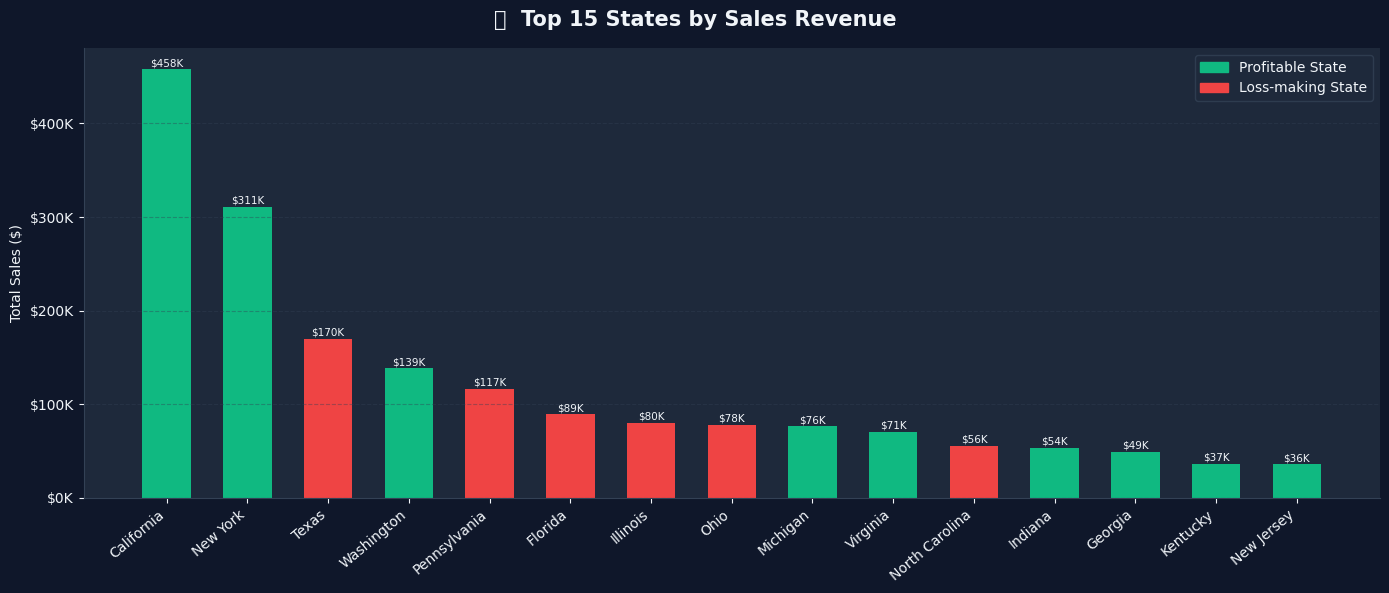

In [12]:
# ── Top 15 States Bar Chart ──
state_sales = df.groupby('State').agg(
    Sales  = ('Sales',  'sum'),
    Profit = ('Profit', 'sum')
).sort_values('Sales', ascending=False).head(15).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('🗺️  Top 15 States by Sales Revenue', fontsize=15, fontweight='bold')

bar_colors = [PALETTE[1] if p > 0 else PALETTE[3] for p in state_sales['Profit']]
bars = ax.bar(state_sales['State'], state_sales['Sales'],
              color=bar_colors, edgecolor='none', width=0.6)
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e3:.0f}K'))
ax.set_xticklabels(state_sales['State'], rotation=40, ha='right')
ax.grid(axis='y')

# Value labels
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1000,
            f'${h/1e3:.0f}K', ha='center', va='bottom', fontsize=7.5, color=TEXT)

profit_pos = mpatches.Patch(color=PALETTE[1], label='Profitable State')
profit_neg = mpatches.Patch(color=PALETTE[3], label='Loss-making State')
ax.legend(handles=[profit_pos, profit_neg], facecolor=PANEL, edgecolor=GRID)
plt.tight_layout()
plt.show()

# ── Interactive USA Choropleth Map (Plotly) ──
all_states = df.groupby('State').agg(Sales=('Sales','sum'), Profit=('Profit','sum')).reset_index()

# US state abbreviation map
us_state_abbrev = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA',
    'Colorado':'CO','Connecticut':'CT','Delaware':'DE','Florida':'FL','Georgia':'GA',
    'Hawaii':'HI','Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA',
    'Kansas':'KS','Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD',
    'Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS',
    'Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV','New Hampshire':'NH',
    'New Jersey':'NJ','New Mexico':'NM','New York':'NY','North Carolina':'NC',
    'North Dakota':'ND','Ohio':'OH','Oklahoma':'OK','Oregon':'OR','Pennsylvania':'PA',
    'Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD','Tennessee':'TN',
    'Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA','Washington':'WA',
    'West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY','District of Columbia':'DC'
}
all_states['Code'] = all_states['State'].map(us_state_abbrev)

fig_map = px.choropleth(
    all_states, locations='Code', locationmode='USA-states',
    color='Sales', hover_name='State',
    hover_data={'Profit': ':$,.0f', 'Sales': ':$,.0f'},
    color_continuous_scale='Blues',
    scope='usa',
    title='🗺️ Sales by State — USA Heatmap'
)
fig_map.update_layout(
    paper_bgcolor='#0F172A', geo_bgcolor='#0F172A',
    font_color='#F1F5F9', title_font_size=15
)
fig_map.show()

## 7️⃣ Segment Performance Analysis

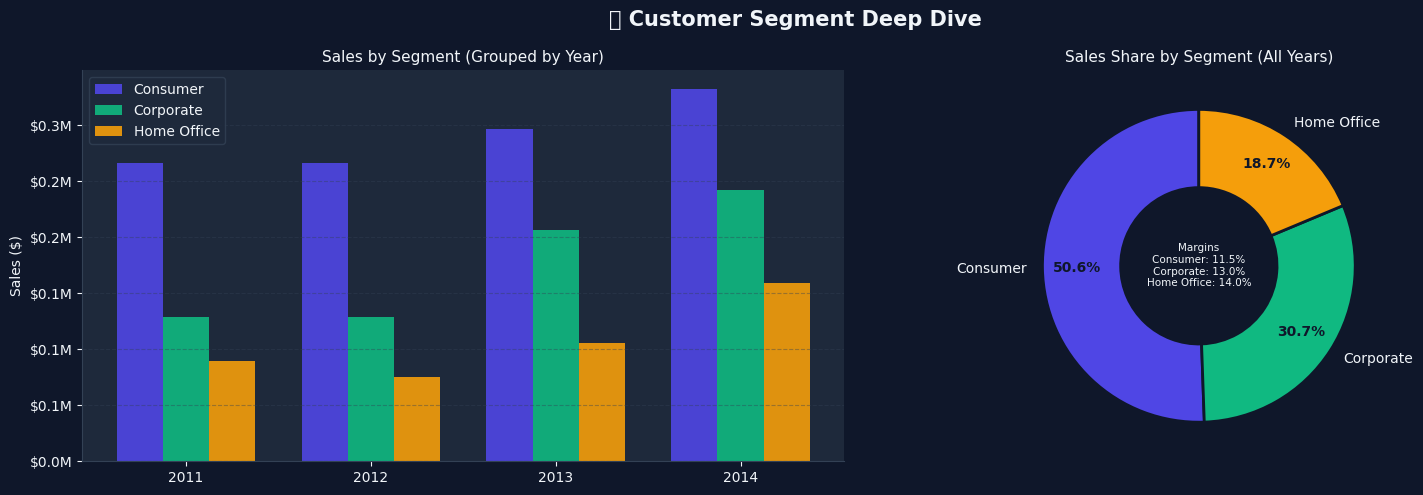

In [13]:
seg = df.groupby(['Year','Segment']).agg(
    Sales  = ('Sales',  'sum'),
    Profit = ('Profit', 'sum'),
    Orders = ('Order ID', 'nunique')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('👥 Customer Segment Deep Dive', fontsize=15, fontweight='bold')

# Clustered bar: Sales by Segment per Year
ax = axes[0]
segments = seg['Segment'].unique()
years    = sorted(seg['Year'].unique())
x = np.arange(len(years))
width = 0.25

for i, (seg_name, color) in enumerate(zip(segments, PALETTE)):
    vals = seg[seg['Segment']==seg_name].sort_values('Year')['Sales'].values
    ax.bar(x + i*width, vals, width, label=seg_name, color=color, edgecolor='none', alpha=0.9)

ax.set_xticks(x + width)
ax.set_xticklabels(years)
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e6:.1f}M'))
ax.set_title('Sales by Segment (Grouped by Year)', fontsize=11)
ax.legend(facecolor=PANEL, edgecolor=GRID)
ax.grid(axis='y')

# Profit Margin donut per segment (all years)
ax2 = axes[1]
seg_total = df.groupby('Segment').agg(Sales=('Sales','sum'), Profit=('Profit','sum')).reset_index()
seg_total['Margin'] = (seg_total['Profit']/seg_total['Sales'])*100

wedges, _, autotexts = ax2.pie(
    seg_total['Sales'], labels=seg_total['Segment'],
    autopct='%1.1f%%', colors=PALETTE[:3], startangle=90,
    pctdistance=0.78, wedgeprops=dict(width=0.5, edgecolor=BG, linewidth=2)
)
for at in autotexts: at.set_color(BG); at.set_fontweight('bold')
ax2.set_title('Sales Share by Segment (All Years)', fontsize=11)

# Add margin text in centre
margin_lines = '\n'.join([f"{r['Segment']}: {r['Margin']:.1f}%" for _,r in seg_total.iterrows()])
ax2.text(0, 0, f'Margins\n{margin_lines}', ha='center', va='center',
         fontsize=7.5, color=TEXT)

plt.tight_layout()
plt.show()

## 8️⃣ Ship Mode & Discount Impact on Profit

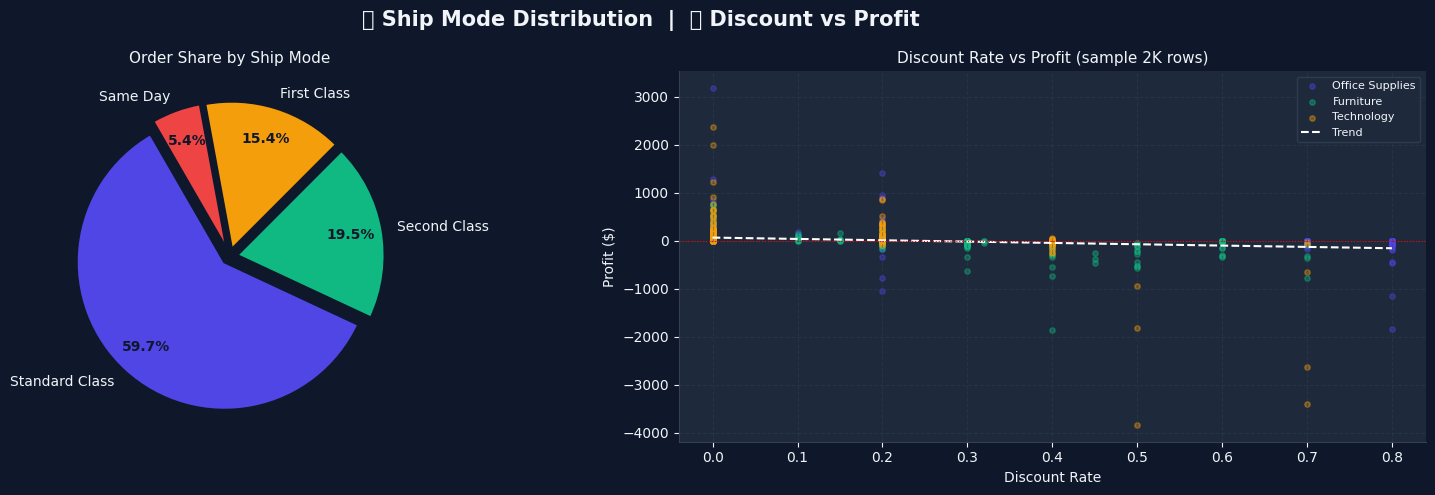


📉 Correlation between Discount & Profit: -0.219
   → As discount increases, profit tends to decrease significantly.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('🚚 Ship Mode Distribution  |  💸 Discount vs Profit', fontsize=15, fontweight='bold')

# ── Exploded Pie: Ship Mode ──
ax = axes[0]
ship = df['Ship Mode'].value_counts()
explode = [0.05] * len(ship)
wedges, texts, autotexts = ax.pie(
    ship.values, labels=ship.index, autopct='%1.1f%%',
    colors=PALETTE[:len(ship)], explode=explode,
    startangle=120, pctdistance=0.78,
    wedgeprops=dict(edgecolor=BG, linewidth=2)
)
for t in texts: t.set_color(TEXT)
for at in autotexts: at.set_color(BG); at.set_fontweight('bold')
ax.set_title('Order Share by Ship Mode', fontsize=11)

# ── Scatter: Discount vs Profit ──
ax2 = axes[1]
sample = df.sample(min(2000, len(df)), random_state=42)
cats   = sample['Category'].unique()
for cat_name, color in zip(cats, PALETTE):
    mask = sample['Category'] == cat_name
    ax2.scatter(sample[mask]['Discount'], sample[mask]['Profit'],
                color=color, alpha=0.4, s=15, label=cat_name)

# Trend line
z = np.polyfit(sample['Discount'], sample['Profit'], 1)
p = np.poly1d(z)
xline = np.linspace(0, sample['Discount'].max(), 100)
ax2.plot(xline, p(xline), color='white', linewidth=1.5, linestyle='--', label='Trend')
ax2.axhline(0, color='red', linewidth=0.8, linestyle=':')

ax2.set_xlabel('Discount Rate')
ax2.set_ylabel('Profit ($)')
ax2.set_title('Discount Rate vs Profit (sample 2K rows)', fontsize=11)
ax2.legend(facecolor=PANEL, edgecolor=GRID, fontsize=8)
ax2.grid(True)

plt.tight_layout()
plt.show()

# Key insight
corr = df['Discount'].corr(df['Profit'])
print(f'\n📉 Correlation between Discount & Profit: {corr:.3f}')
print('   → As discount increases, profit tends to decrease significantly.')

## 9️⃣ Interactive Mini-Dashboard (Plotly)

In [15]:
# ── 2x2 Plotly Interactive Dashboard ───────────────────────────────
fig_dash = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Revenue & Profit by Year',
        'Monthly Sales Trend (All Years)',
        'Profit by Category & Region',
        'Top 10 Sub-Categories by Sales'
    ),
    specs=[[{"type": "bar"}, {"type": "scatter"}],
           [{"type": "bar"}, {"type": "bar"}]]
)

PLOTLY_COLORS = ['#4F46E5', '#10B981', '#F59E0B', '#EF4444']

# ── Plot 1: Revenue & Profit by Year ──
yoy2 = df.groupby('Year').agg(Revenue=('Sales','sum'), Profit=('Profit','sum')).reset_index()
fig_dash.add_trace(
    go.Bar(name='Revenue', x=yoy2['Year'].astype(str), y=yoy2['Revenue'],
           marker_color=PLOTLY_COLORS[0], text=[f'${v/1e6:.2f}M' for v in yoy2['Revenue']],
           textposition='outside'), row=1, col=1)
fig_dash.add_trace(
    go.Bar(name='Profit', x=yoy2['Year'].astype(str), y=yoy2['Profit'],
           marker_color=PLOTLY_COLORS[1], text=[f'${v/1e3:.0f}K' for v in yoy2['Profit']],
           textposition='outside'), row=1, col=1)

# ── Plot 2: Monthly Sales Line ──
monthly2 = df.groupby('Month').agg(Sales=('Sales','sum')).reset_index()
fig_dash.add_trace(
    go.Scatter(x=MONTHS_ORDER, y=monthly2['Sales'],
               mode='lines+markers', name='Monthly Sales',
               line=dict(color=PLOTLY_COLORS[2], width=2),
               marker=dict(size=7)), row=1, col=2)

# ── Plot 3: Profit by Category & Region ──
cat_reg = df.groupby(['Region','Category']).agg(Profit=('Profit','sum')).reset_index()
for i, cat_name in enumerate(cat_reg['Category'].unique()):
    d = cat_reg[cat_reg['Category']==cat_name]
    fig_dash.add_trace(
        go.Bar(name=cat_name, x=d['Region'], y=d['Profit'],
               marker_color=PLOTLY_COLORS[i % len(PLOTLY_COLORS)],
               showlegend=(True if i < 3 else False)), row=2, col=1)

# ── Plot 4: Top 10 Sub-Category Sales ──
subcat2 = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True).tail(10)
fig_dash.add_trace(
    go.Bar(x=subcat2.values, y=subcat2.index, orientation='h',
           marker_color=PLOTLY_COLORS[0], name='Sub-Cat Sales',
           showlegend=False), row=2, col=2)

fig_dash.update_layout(
    height=700,
    title_text='📊 E-Commerce Sales Dashboard — Interactive',
    title_font_size=16,
    barmode='group',
    paper_bgcolor='#0F172A',
    plot_bgcolor='#1E293B',
    font=dict(color='#F1F5F9'),
    legend=dict(bgcolor='#1E293B', bordercolor='#334155')
)
fig_dash.update_xaxes(gridcolor='#334155', showgrid=True)
fig_dash.update_yaxes(gridcolor='#334155', showgrid=True)
fig_dash.show()

## 🔟 Key Insights & Business Recommendations

In [16]:
print('=' * 65)
print('     📌  KEY BUSINESS INSIGHTS')
print('=' * 65)

total_sales  = df['Sales'].sum()
total_profit = df['Profit'].sum()
margin       = (total_profit / total_sales) * 100
best_cat     = df.groupby('Category')['Profit'].sum().idxmax()
worst_subcat = df.groupby('Sub-Category')['Profit'].sum().idxmin()
best_state   = df.groupby('State')['Sales'].sum().idxmax()
best_month   = df.groupby('Month Name')['Sales'].sum().idxmax()
disc_corr    = df['Discount'].corr(df['Profit'])

insights = [
    f"💰 Total Revenue   : ${total_sales:,.0f}",
    f"📈 Total Profit    : ${total_profit:,.0f}",
    f"📊 Avg Profit Margin: {margin:.2f}%",
    f"🏆 Most Profitable Category : {best_cat}",
    f"⚠️  Worst Sub-Category (Loss): {worst_subcat}",
    f"🗺️  Top Revenue State       : {best_state}",
    f"📅 Peak Sales Month         : {best_month}",
    f"📉 Discount-Profit Correlation: {disc_corr:.3f}  (negative = harmful)",
]

for line in insights:
    print(f'  {line}')

print('\n' + '=' * 65)
print('     💡  RECOMMENDATIONS')
print('=' * 65)
recs = [
    "1. Cap discounts below 20% — high discounts consistently destroy profit.",
    f"2. Expand inventory in {best_state} — top revenue generator.",
    f"3. Investigate {worst_subcat} sub-category for cost reduction or discontinuation.",
    "4. Boost Q4 (Nov–Dec) marketing budget — seasonal revenue peaks here.",
    "5. Target Corporate segment — higher order values and margins vs Consumer.",
]
for r in recs:
    print(f'  {r}')
print('=' * 65)

     📌  KEY BUSINESS INSIGHTS
  💰 Total Revenue   : $2,297,201
  📈 Total Profit    : $286,397
  📊 Avg Profit Margin: 12.47%
  🏆 Most Profitable Category : Technology
  ⚠️  Worst Sub-Category (Loss): Tables
  🗺️  Top Revenue State       : California
  📅 Peak Sales Month         : Nov
  📉 Discount-Profit Correlation: -0.219  (negative = harmful)

     💡  RECOMMENDATIONS
  1. Cap discounts below 20% — high discounts consistently destroy profit.
  2. Expand inventory in California — top revenue generator.
  3. Investigate Tables sub-category for cost reduction or discontinuation.
  4. Boost Q4 (Nov–Dec) marketing budget — seasonal revenue peaks here.
  5. Target Corporate segment — higher order values and margins vs Consumer.
